In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the Titanic dataset
titanic = sns.load_dataset('titanic')

In [ ]:
titanic.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [ ]:
# Fill missing 'age' with the median value
titanic['age'].fillna(titanic['age'].median(), inplace=True)
# Fill missing 'embarked' with the mode
titanic['embarked'].fillna(titanic['embarked'].mode()[0], inplace=True)
# Drop the 'deck' column due to many missing values
titanic.drop(columns=['deck'], inplace=True)
# Drop rows with missing 'embark_town'
titanic.dropna(subset=['embark_town'], inplace=True)

/tmp/ipython-input-691358889.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].median(), inplace=True)
/tmp/ipython-input-691358889.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [ ]:
# Verify data cleaning
print(titanic.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


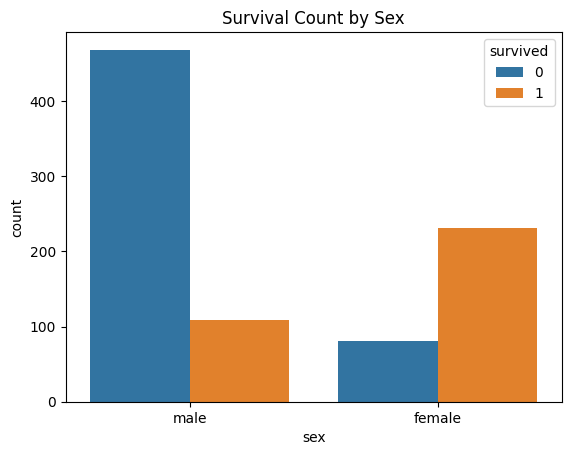

In [ ]:
sns.countplot(x='sex', hue='survived', data=titanic)
plt.title('Survival Count by Sex')
plt.show()
# higher proportion of females survived compared to males.

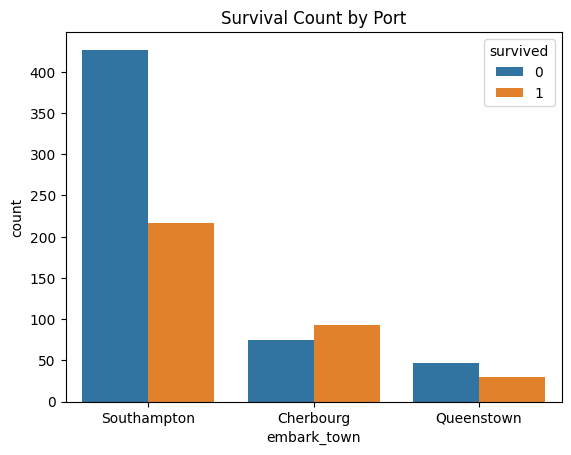

In [ ]:
sns.countplot(x='embark_town', hue='survived', data=titanic)
plt.title('Survival Count by Port')
plt.show()

# Queenstown  had the fewest passengers and a lower survival rate among its passengers.
# Southampton had the highest number of passengers overall, and also the highest number of casualties.

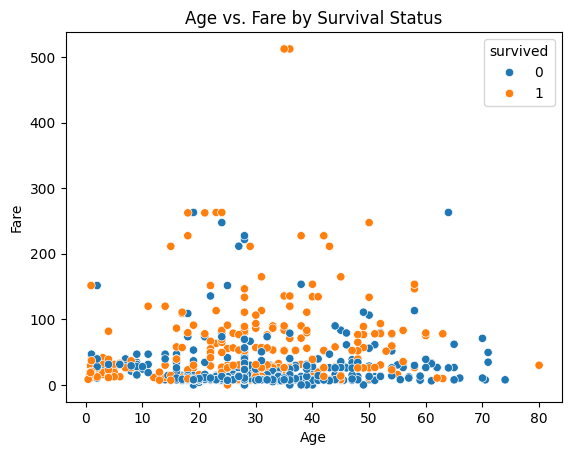

In [ ]:
sns.scatterplot(x='age', y='fare', hue='survived', data=titanic)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs. Fare by Survival Status')
plt.show()
# as the fare increases the number of blue dots decrease and nearly only orange dots
# as the fare decreases there is domination for the blue dots

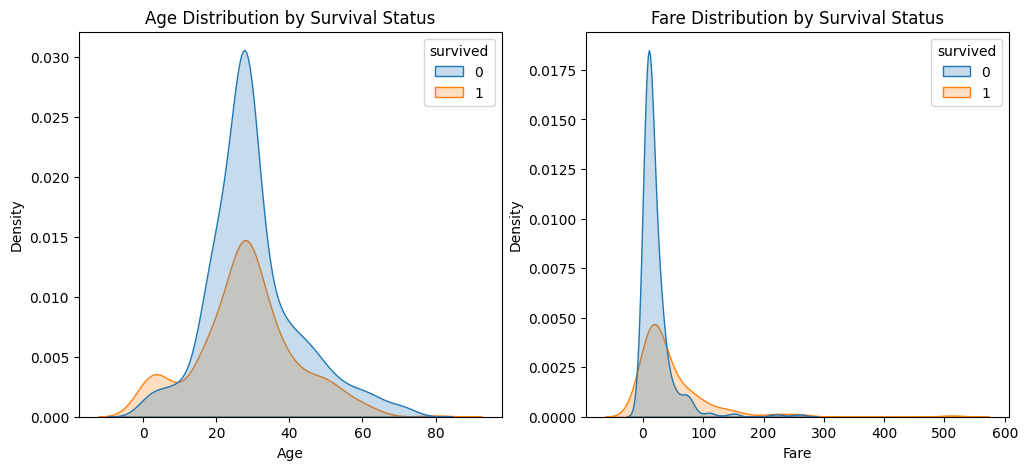

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(x='age', hue='survived', data=titanic, fill=True)
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.subplot(1, 2, 2)
sns.kdeplot(x='fare', hue='survived', data=titanic, fill=True)
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Fare')
plt.ylabel('Density')

plt.show()

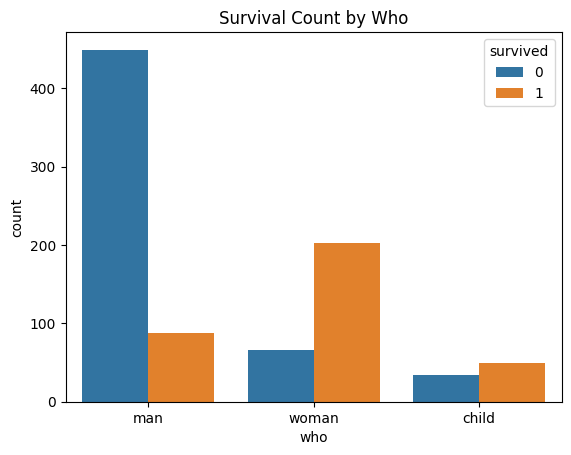

In [ ]:
sns.countplot(x='who', hue='survived', data=titanic)
plt.title('Survival Count by Who')
plt.show()
# Women and children exhibited a significantly higher survival rate compared to men.

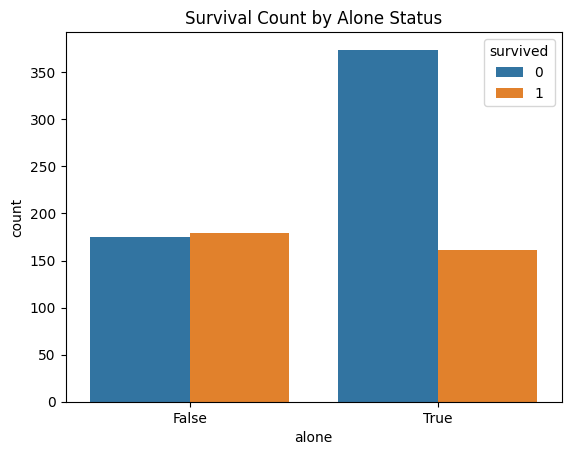

In [ ]:
sns.countplot(x='alone', hue='survived', data=titanic)
plt.title('Survival Count by Alone Status')
plt.show()
# higher number of passengers were traveling alone
# and a larger proportion of them did not survive compared to those traveling with companions.

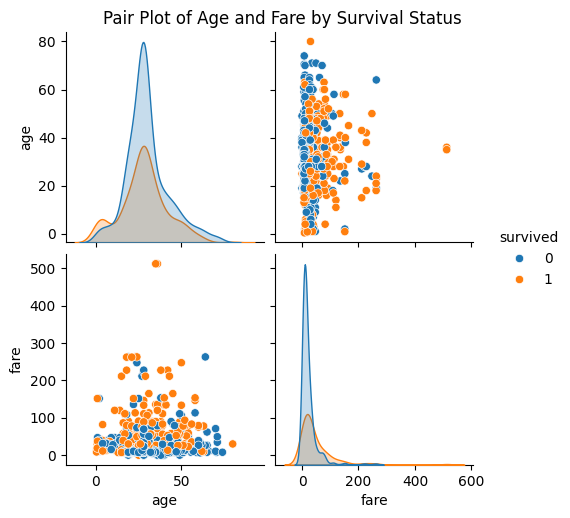

In [ ]:
sns.pairplot(titanic, hue='survived', vars=['age', 'fare'])
plt.suptitle('Pair Plot of Age and Fare by Survival Status', y=1.02)
plt.show()